In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_MAX = 35
ODE_STEPS_PER_DAY = 20

# Initial parameter guesses used as optimization starting points.
# These are not fixed universal constants.
# The maturity-decline terms are initialized at zero to start from a neutral ssumption of no delayed decline in specific growth rate.
MODEL_INIT = {
    "dynamic": {
        "mu_max": 0.30,
        "Ks": 2.0,
        "m": 0.0,
        "delay": 0.0,
    },
    "rmnd": {
        "mu_max_N": 0.30,
        "mu_max_MSS": 0.30,
        "KsN": 2.0,
        "KsP": 0.10,
        "KsK": 0.30,
        "m_N": 0.0,
        "m_MSS": 0.0,
        "delay_N": 0.0,
        "delay_MSS": 0.0,
    },
    "smnd": {
        "mu_max": 0.30,
        "KsN": 2.0,
        "KsP": 0.10,
        "KsK": 0.30,
        "m": 0.0,
        "delay": 0.0,
    },
    "monod": {
        "mu_max": 0.25,
        "KsN": 1.0,
        "KsP": 0.05,
        "KsK": 0.10,
    },
}


def frac_monod(s, ks):
    s = max(float(s), 1e-12)
    ks = max(float(ks), 1e-12)
    return s / (ks + s)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def metrics_dict(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred) if len(y_true) >= 2 else np.nan,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
    }


def build_plot_grid():
    return np.linspace(0, X_MAX, X_MAX + 1)


def forcing_N_at_time(tt, forcing):
    return np.interp(
        tt, forcing["t"], forcing["N"],
        left=forcing["N"][0], right=forcing["N"][-1]
    )


def forcing_P_at_time(tt, forcing):
    return np.interp(
        tt, forcing["t"], forcing["P"],
        left=forcing["P"][0], right=forcing["P"][-1]
    )


def forcing_K_at_time(tt, forcing):
    return np.interp(
        tt, forcing["t"], forcing["K"],
        left=forcing["K"][0], right=forcing["K"][-1]
    )


def calc_mu_dynamic(t, forcing, params, category):
    # Nitrogen-focused dynamic μ model
    N = forcing_N_at_time(t, forcing)
    mu = params["mu_max"] * frac_monod(N, params["Ks"])
    mu += params["m"] * max(0.0, t - params["delay"])
    return mu


def calc_mu_rmnd(t, forcing, params, category):
    # Category-aware multi-nutrient dynamic μ model
    N = forcing_N_at_time(t, forcing)
    P = forcing_P_at_time(t, forcing)
    K = forcing_K_at_time(t, forcing)

    if category == "MSS":
        mu_max = params["mu_max_MSS"]
        m = params["m_MSS"]
        delay = params["delay_MSS"]
    else:
        mu_max = params["mu_max_N"]
        m = params["m_N"]
        delay = params["delay_N"]

    mu = mu_max
    mu *= frac_monod(N, params["KsN"])
    mu *= frac_monod(P, params["KsP"])
    mu *= frac_monod(K, params["KsK"])
    mu += m * max(0.0, t - delay)
    return mu


def calc_mu_smnd(t, forcing, params, category):
    # Shared multi-nutrient dynamic μ model
    N = forcing_N_at_time(t, forcing)
    P = forcing_P_at_time(t, forcing)
    K = forcing_K_at_time(t, forcing)

    mu = params["mu_max"]
    mu *= frac_monod(N, params["KsN"])
    mu *= frac_monod(P, params["KsP"])
    mu *= frac_monod(K, params["KsK"])
    mu += params["m"] * max(0.0, t - params["delay"])
    return mu


def calc_mu_liebig(t, forcing, params, category):
    # Liebig minimum Monod model
    N = forcing_N_at_time(t, forcing)
    P = forcing_P_at_time(t, forcing)
    K = forcing_K_at_time(t, forcing)

    fmin = min(
        frac_monod(N, params["KsN"]),
        frac_monod(P, params["KsP"]),
        frac_monod(K, params["KsK"]),
    )
    return params["mu_max"] * fmin


def calc_mu_multiplicative(t, forcing, params, category):
    # Multiplicative Monod model
    N = forcing_N_at_time(t, forcing)
    P = forcing_P_at_time(t, forcing)
    K = forcing_K_at_time(t, forcing)

    mu = params["mu_max"]
    mu *= frac_monod(N, params["KsN"])
    mu *= frac_monod(P, params["KsP"])
    mu *= frac_monod(K, params["KsK"])
    return mu


def biomass_ode(y, t, forcing, params, category, model_name):
    # Biomass governing equation: dDM/dt = μ * DM
    B = y[0]

    if model_name == "dynamic":
        mu = calc_mu_dynamic(t, forcing, params, category)
    elif model_name == "rmnd":
        mu = calc_mu_rmnd(t, forcing, params, category)
    elif model_name == "smnd":
        mu = calc_mu_smnd(t, forcing, params, category)
    elif model_name == "liebig":
        mu = calc_mu_liebig(t, forcing, params, category)
    elif model_name == "multiplicative":
        mu = calc_mu_multiplicative(t, forcing, params, category)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    dBdt = mu * B
    return np.array([dBdt])


def rk4_step_scalar(ode_fun, y, t, dt, *args):
    k1 = ode_fun(y, t, *args)
    k2 = ode_fun(y + dt / 2 * k1, t + dt / 2, *args)
    k3 = ode_fun(y + dt / 2 * k2, t + dt / 2, *args)
    k4 = ode_fun(y + dt * k3, t + dt, *args)
    return y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def simulate_biomass(model_name, forcing, params, category, B0, days_obs):
    # Simulate DM from day 0 to day 35
    t_dense = np.linspace(0, X_MAX, int(X_MAX * ODE_STEPS_PER_DAY) + 1)
    dt = t_dense[1] - t_dense[0]

    y = np.array([B0], dtype=float)
    sol = []

    for ti in t_dense:
        sol.append(y.copy())
        y = rk4_step_scalar(
            biomass_ode, y, ti, dt,
            forcing, params, category, model_name
        )

    sol = np.array(sol)
    B_dense = sol[:, 0]

    B_fit = np.interp(days_obs, t_dense, B_dense)
    t_plot = build_plot_grid()
    B_plot = np.interp(t_plot, t_dense, B_dense)

    return t_plot, B_plot, B_fit

In [2]:
import pandas as pd
from scipy.optimize import minimize

# File and sheet settings
EXCEL_FILE = "/Users/yuming/Desktop/Folders/VerticalFarm/NPK.CrossT.All.xlsx"
FIT_SHEET_NAME = "ModSummary"
PLOT_SHEET_NAME = "ModPlant"

# All treatment categories
ALL_CATEGORIES = ["N", "P", "K", "MSS"]

CATEGORY_TREATMENT_ORDER_ALL = {
    "N": ["R39", "R13", "R09N", "R14", "R09S", "R22", "R11n12"],
    "P": ["R21", "R19", "R15t17N", "R15t17S", "R22P"],
    "K": ["R34", "R25", "R24", "R23N", "R23S", "R22K"],
    "MSS": ["R22N", "MSS"],
}

TREATMENT_LABEL_MAP = {
    "R39":     "(5 mg L$^{-1}$) N Treatment",
    "R13":     "(11 mg L$^{-1}$) N Treatment",
    "R09N":    "(25 mg L$^{-1}$) N Treatment",
    "R14":     "(33 mg L$^{-1}$) N Treatment",
    "R09S":    "(66 mg L$^{-1}$) N Treatment",
    "R22":     "(132 mg L$^{-1}$) N Treatment",
    "R11n12":  "(264 mg L$^{-1}$) N Treatment",
    "R21":     "(1 mg L$^{-1}$) P Treatment",
    "R19":     "(2 mg L$^{-1}$) P Treatment",
    "R15t17N": "(5 mg L$^{-1}$) P Treatment",
    "R15t17S": "(12 mg L$^{-1}$) P Treatment",
    "R22P":    "(31 mg L$^{-1}$) P Treatment",
    "R34":     "(2 mg L$^{-1}$) K Treatment",
    "R25":     "(13 mg L$^{-1}$) K Treatment",
    "R24":     "(21 mg L$^{-1}$) K Treatment",
    "R23N":    "(42 mg L$^{-1}$) K Treatment",
    "R23S":    "(105 mg L$^{-1}$) K Treatment",
    "R22K":    "(210 mg L$^{-1}$) K Treatment",
    "R22N":    "MSS Treatment",
    "MSS":     "MSS Treatment",
}

CATEGORY_NAME_MAP_ALL = {
    "N": "N-limited",
    "P": "P-limited",
    "K": "K-limited",
    "MSS": "MSS",
}


def infer_limiting_group_all(treatment_name):
    t = str(treatment_name).strip()
    if t in {"R39", "R13", "R09N", "R14", "R09S", "R22", "R11n12"}:
        return "N"
    if t in {"R21", "R19", "R15t17N", "R15t17S", "R22P"}:
        return "P"
    if t in {"R34", "R25", "R24", "R23N", "R23S", "R22K"}:
        return "K"
    if t in {"R22N", "MSS"}:
        return "MSS"
    return None


def display_treatment_label(treatment):
    return TREATMENT_LABEL_MAP.get(str(treatment).strip(), str(treatment).strip())


def display_category_label_all(category):
    return CATEGORY_NAME_MAP_ALL.get(category, category)


def build_treatment_forcing(sub_fit):
    N0 = float(sub_fit["N"].iloc[0])
    P0 = float(sub_fit["P"].iloc[0])
    K0 = float(sub_fit["K"].iloc[0])

    forcing = {
        "t": np.array([0.0, X_MAX], dtype=float),
        "N": np.array([N0, N0], dtype=float),
        "P": np.array([P0, P0], dtype=float),
        "K": np.array([K0, K0], dtype=float),
    }
    return forcing


def load_fit_data_dm_all():
    df = pd.read_excel(EXCEL_FILE, sheet_name=FIT_SHEET_NAME, header=1)

    required = [
        "Treatment", "Growth Day", "Limiting Nutrient",
        "DM", "Treatment %",
        "Sample Period Avg [N]", "Sample Period Avg [P]", "Sample Period Avg [K]",
        "Lifetime Avg [N]", "Lifetime Avg [P]", "Lifetime Avg [K]",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing fit columns: {missing}")

    use_cols = required.copy()
    if "Mass Screening" in df.columns:
        use_cols.append("Mass Screening")

    use = df[use_cols].copy().rename(columns={"DM": "Y_DM"})

    numeric_cols = [
        "Growth Day", "Y_DM",
        "Sample Period Avg [N]", "Sample Period Avg [P]", "Sample Period Avg [K]",
        "Lifetime Avg [N]", "Lifetime Avg [P]", "Lifetime Avg [K]"
    ]
    for c in numeric_cols:
        use[c] = pd.to_numeric(use[c], errors="coerce")

    use["Treatment"] = use["Treatment"].astype(str).str.strip()
    use["Treatment %"] = use["Treatment %"].astype(str).str.strip()

    if "Mass Screening" in use.columns:
        use["Mass Screening"] = use["Mass Screening"].astype(str).str.strip()

    use = use[(~use["Y_DM"].isna()) & (use["Y_DM"] != 0)].copy()
    use = use[use["Treatment %"] != "Seedlings"].copy()
    use = use[use["Treatment %"] != "2"].copy()

    if "Mass Screening" in use.columns:
        use = use[~use["Mass Screening"].isin(["Screen", "Screened"])].copy()

    use["N"] = use["Sample Period Avg [N]"].fillna(use["Lifetime Avg [N]"])
    use["P"] = use["Sample Period Avg [P]"].fillna(use["Lifetime Avg [P]"])
    use["K"] = use["Sample Period Avg [K]"].fillna(use["Lifetime Avg [K]"])

    use = use.dropna(subset=["Treatment", "Growth Day", "Y_DM", "N", "P", "K"]).copy()
    use["Category"] = use["Treatment"].map(infer_limiting_group_all)
    use = use[use["Category"].isin(ALL_CATEGORIES)].copy()

    fit_df = (
        use.groupby(["Treatment", "Growth Day", "Category"], as_index=False)
        .agg({"Y_DM": "mean", "N": "mean", "P": "mean", "K": "mean"})
    )
    return fit_df.reset_index(drop=True)


def load_plot_data_dm_all():
    df = pd.read_excel(EXCEL_FILE, sheet_name=PLOT_SHEET_NAME, header=1)

    required = ["Treatment", "Growth Day", "Total DM (g)"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing plot columns: {missing}")

    out = df[required].copy().rename(columns={"Total DM (g)": "Y_DM"})
    out["Treatment"] = out["Treatment"].astype(str).str.strip()
    out["Growth Day"] = pd.to_numeric(out["Growth Day"], errors="coerce")
    out["Y_DM"] = pd.to_numeric(out["Y_DM"], errors="coerce")

    out = out.dropna(subset=["Treatment", "Growth Day", "Y_DM"]).copy()
    out["Category"] = out["Treatment"].map(infer_limiting_group_all)
    out = out[out["Category"].isin(ALL_CATEGORIES)].copy()

    return out.reset_index(drop=True)


def sse(y_true, y_pred):
    diff = np.asarray(y_true) - np.asarray(y_pred)
    return np.sum(diff ** 2)


def fit_dynamic_dm_all(fit_df):
    init = MODEL_INIT["dynamic"]

    def objective(theta):
        mu_max, Ks, m, delay = theta
        params = {"mu_max": mu_max, "Ks": Ks, "m": m, "delay": delay}

        total = 0.0
        for treatment in sorted(fit_df["Treatment"].unique()):
            sub_fit = fit_df[fit_df["Treatment"] == treatment].sort_values("Growth Day")
            category = sub_fit["Category"].iloc[0]
            forcing = build_treatment_forcing(sub_fit)
            days_obs = sub_fit["Growth Day"].values.astype(float)
            y_dm_obs = sub_fit["Y_DM"].values.astype(float)
            B0_dm = float(y_dm_obs[0])

            _, _, y_dm_pred = simulate_biomass("dynamic", forcing, params, category, B0_dm, days_obs)
            total += sse(y_dm_obs, y_dm_pred)

        return total

    x0 = np.array([init["mu_max"], init["Ks"], init["m"], init["delay"]], dtype=float)
    bounds = [(1e-6, 2.0), (1e-6, 500.0), (-0.2, 0.0), (0.0, 40.0)]
    res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
    return {
        "mu_max": res.x[0], "Ks": res.x[1], "m": res.x[2], "delay": res.x[3],
        "success": res.success, "objective": res.fun,
    }


def fit_rmnd_dm_all(fit_df):
    init = MODEL_INIT["rmnd"]

    def objective(theta):
        mu_max_N, mu_max_MSS, KsN, KsP, KsK, m_N, m_MSS, delay_N, delay_MSS = theta
        params = {
            "mu_max_N": mu_max_N, "mu_max_MSS": mu_max_MSS,
            "KsN": KsN, "KsP": KsP, "KsK": KsK,
            "m_N": m_N, "m_MSS": m_MSS,
            "delay_N": delay_N, "delay_MSS": delay_MSS,
        }

        total = 0.0
        for treatment in sorted(fit_df["Treatment"].unique()):
            sub_fit = fit_df[fit_df["Treatment"] == treatment].sort_values("Growth Day")
            category = sub_fit["Category"].iloc[0]
            forcing = build_treatment_forcing(sub_fit)
            days_obs = sub_fit["Growth Day"].values.astype(float)
            y_dm_obs = sub_fit["Y_DM"].values.astype(float)
            B0_dm = float(y_dm_obs[0])

            _, _, y_dm_pred = simulate_biomass("rmnd", forcing, params, category, B0_dm, days_obs)
            total += sse(y_dm_obs, y_dm_pred)

        return total

    x0 = np.array([
        init["mu_max_N"], init["mu_max_MSS"],
        init["KsN"], init["KsP"], init["KsK"],
        init["m_N"], init["m_MSS"],
        init["delay_N"], init["delay_MSS"]
    ], dtype=float)
    bounds = [
        (1e-6, 2.0), (1e-6, 2.0),
        (1e-6, 500.0), (1e-6, 500.0), (1e-6, 500.0),
        (-0.2, 0.0), (-0.2, 0.0),
        (0.0, 40.0), (0.0, 40.0),
    ]
    res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
    return {
        "mu_max_N": res.x[0], "mu_max_MSS": res.x[1],
        "KsN": res.x[2], "KsP": res.x[3], "KsK": res.x[4],
        "m_N": res.x[5], "m_MSS": res.x[6],
        "delay_N": res.x[7], "delay_MSS": res.x[8],
        "success": res.success, "objective": res.fun,
    }


def fit_smnd_dm_all(fit_df):
    init = MODEL_INIT["smnd"]

    def objective(theta):
        mu_max, KsN, KsP, KsK, m, delay = theta
        params = {
            "mu_max": mu_max, "KsN": KsN, "KsP": KsP, "KsK": KsK,
            "m": m, "delay": delay,
        }

        total = 0.0
        for treatment in sorted(fit_df["Treatment"].unique()):
            sub_fit = fit_df[fit_df["Treatment"] == treatment].sort_values("Growth Day")
            category = sub_fit["Category"].iloc[0]
            forcing = build_treatment_forcing(sub_fit)
            days_obs = sub_fit["Growth Day"].values.astype(float)
            y_dm_obs = sub_fit["Y_DM"].values.astype(float)
            B0_dm = float(y_dm_obs[0])

            _, _, y_dm_pred = simulate_biomass("smnd", forcing, params, category, B0_dm, days_obs)
            total += sse(y_dm_obs, y_dm_pred)

        return total

    x0 = np.array([
        init["mu_max"], init["KsN"], init["KsP"], init["KsK"],
        init["m"], init["delay"]
    ], dtype=float)
    bounds = [
        (1e-6, 2.0),
        (1e-6, 500.0), (1e-6, 500.0), (1e-6, 500.0),
        (-0.2, 0.0), (0.0, 40.0),
    ]
    res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
    return {
        "mu_max": res.x[0], "KsN": res.x[1], "KsP": res.x[2], "KsK": res.x[3],
        "m": res.x[4], "delay": res.x[5],
        "success": res.success, "objective": res.fun,
    }


def fit_liebig_dm_all(fit_df):
    init = MODEL_INIT["monod"]

    def objective(theta):
        mu_max, KsN, KsP, KsK = theta
        params = {"mu_max": mu_max, "KsN": KsN, "KsP": KsP, "KsK": KsK}

        total = 0.0
        for treatment in sorted(fit_df["Treatment"].unique()):
            sub_fit = fit_df[fit_df["Treatment"] == treatment].sort_values("Growth Day")
            category = sub_fit["Category"].iloc[0]
            forcing = build_treatment_forcing(sub_fit)
            days_obs = sub_fit["Growth Day"].values.astype(float)
            y_dm_obs = sub_fit["Y_DM"].values.astype(float)
            B0_dm = float(y_dm_obs[0])

            _, _, y_dm_pred = simulate_biomass("liebig", forcing, params, category, B0_dm, days_obs)
            total += sse(y_dm_obs, y_dm_pred)

        return total

    x0 = np.array([init["mu_max"], init["KsN"], init["KsP"], init["KsK"]], dtype=float)
    bounds = [(1e-6, 2.0), (1e-6, 500.0), (1e-6, 500.0), (1e-6, 500.0)]
    res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
    return {
        "mu_max": res.x[0], "KsN": res.x[1], "KsP": res.x[2], "KsK": res.x[3],
        "success": res.success, "objective": res.fun,
    }


def fit_multiplicative_dm_all(fit_df):
    init = MODEL_INIT["monod"]

    def objective(theta):
        mu_max, KsN, KsP, KsK = theta
        params = {"mu_max": mu_max, "KsN": KsN, "KsP": KsP, "KsK": KsK}

        total = 0.0
        for treatment in sorted(fit_df["Treatment"].unique()):
            sub_fit = fit_df[fit_df["Treatment"] == treatment].sort_values("Growth Day")
            category = sub_fit["Category"].iloc[0]
            forcing = build_treatment_forcing(sub_fit)
            days_obs = sub_fit["Growth Day"].values.astype(float)
            y_dm_obs = sub_fit["Y_DM"].values.astype(float)
            B0_dm = float(y_dm_obs[0])

            _, _, y_dm_pred = simulate_biomass("multiplicative", forcing, params, category, B0_dm, days_obs)
            total += sse(y_dm_obs, y_dm_pred)

        return total

    x0 = np.array([init["mu_max"], init["KsN"], init["KsP"], init["KsK"]], dtype=float)
    bounds = [(1e-6, 2.0), (1e-6, 500.0), (1e-6, 500.0), (1e-6, 500.0)]
    res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
    return {
        "mu_max": res.x[0], "KsN": res.x[1], "KsP": res.x[2], "KsK": res.x[3],
        "success": res.success, "objective": res.fun,
    }


# Load full-category fit and plot data
fit_df_dm_all = load_fit_data_dm_all()
plot_df_dm_all = load_plot_data_dm_all()

print("Used interpreted treatments (all categories):")
print([display_treatment_label(t) for t in sorted(fit_df_dm_all["Treatment"].unique())])
print("Used categories:")
print([display_category_label_all(c) for c in sorted(fit_df_dm_all["Category"].unique())])

# Fit all models on all treatment categories
fitted_params_all = {
    "dynamic": fit_dynamic_dm_all(fit_df_dm_all),
    "rmnd": fit_rmnd_dm_all(fit_df_dm_all),
    "smnd": fit_smnd_dm_all(fit_df_dm_all),
    "liebig": fit_liebig_dm_all(fit_df_dm_all),
    "multiplicative": fit_multiplicative_dm_all(fit_df_dm_all),
}

for k, v in fitted_params_all.items():
    print(f"\n{k}")
    print(v)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Web Extension extension is not supported and will be removed
  warn(msg)


Used interpreted treatments (all categories):
['(25 mg L$^{-1}$) N Treatment', '(66 mg L$^{-1}$) N Treatment', '(264 mg L$^{-1}$) N Treatment', '(11 mg L$^{-1}$) N Treatment', '(33 mg L$^{-1}$) N Treatment', '(5 mg L$^{-1}$) P Treatment', '(12 mg L$^{-1}$) P Treatment', '(2 mg L$^{-1}$) P Treatment', '(1 mg L$^{-1}$) P Treatment', '(132 mg L$^{-1}$) N Treatment', '(42 mg L$^{-1}$) K Treatment', '(105 mg L$^{-1}$) K Treatment', '(21 mg L$^{-1}$) K Treatment', '(13 mg L$^{-1}$) K Treatment', '(2 mg L$^{-1}$) K Treatment', '(5 mg L$^{-1}$) N Treatment']
Used categories:
['K-limited', 'N-limited', 'P-limited']

dynamic
{'mu_max': np.float64(0.4007785239171404), 'Ks': np.float64(2.035219646904974), 'm': np.float64(-0.008683992967534294), 'delay': np.float64(0.025119552560346054), 'success': False, 'objective': np.float64(249.40601284917483)}

rmnd
{'mu_max_N': np.float64(0.4223592538244029), 'mu_max_MSS': np.float64(0.3), 'KsN': np.float64(2.930066871136723), 'KsP': np.float64(0.18668277863


MODEL: Dynamic μ

Per-treatment metrics — DM
    Model  Category                     Treatment        R2    MAE   RMSE
Dynamic μ N-limited  (25 mg L$^{-1}$) N Treatment    0.9557 0.1856 0.2231
Dynamic μ N-limited  (66 mg L$^{-1}$) N Treatment    0.9455 0.2325 0.3792
Dynamic μ N-limited (264 mg L$^{-1}$) N Treatment    0.6035 0.8112 1.1132
Dynamic μ N-limited  (11 mg L$^{-1}$) N Treatment    0.1306 0.3106 0.5808
Dynamic μ N-limited  (33 mg L$^{-1}$) N Treatment    0.7209 0.2976 0.4744
Dynamic μ P-limited   (5 mg L$^{-1}$) P Treatment    0.9790 0.1854 0.3210
Dynamic μ P-limited  (12 mg L$^{-1}$) P Treatment    0.9660 0.2392 0.4740
Dynamic μ P-limited   (2 mg L$^{-1}$) P Treatment    0.3365 0.6798 1.0908
Dynamic μ P-limited   (1 mg L$^{-1}$) P Treatment -139.1536 1.5326 2.5090
Dynamic μ N-limited (132 mg L$^{-1}$) N Treatment    0.6947 1.2430 2.1564
Dynamic μ K-limited  (42 mg L$^{-1}$) K Treatment    0.6521 1.4313 2.5403
Dynamic μ K-limited (105 mg L$^{-1}$) K Treatment    0.8107 0.8700

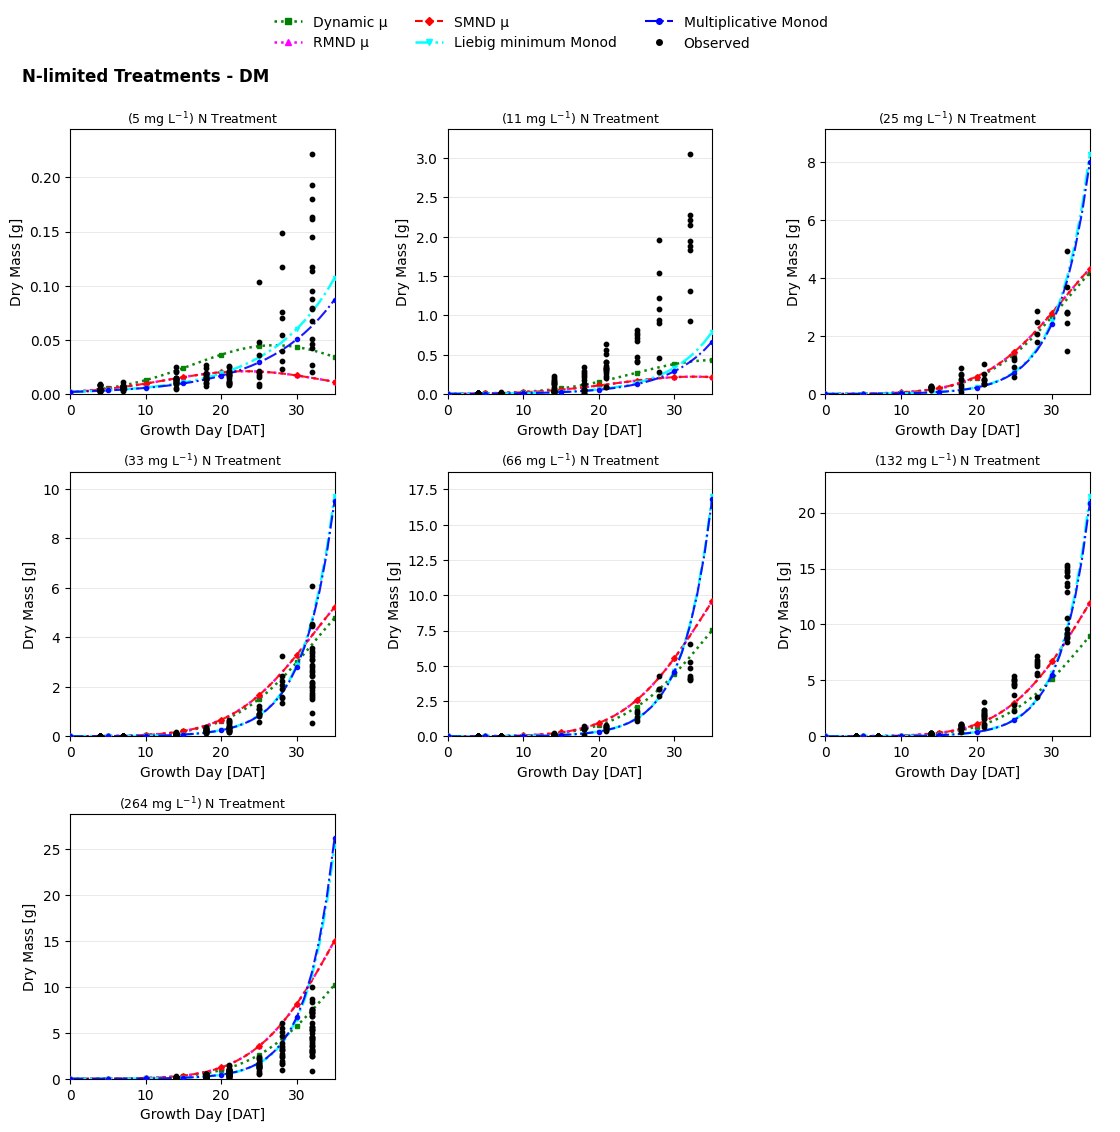

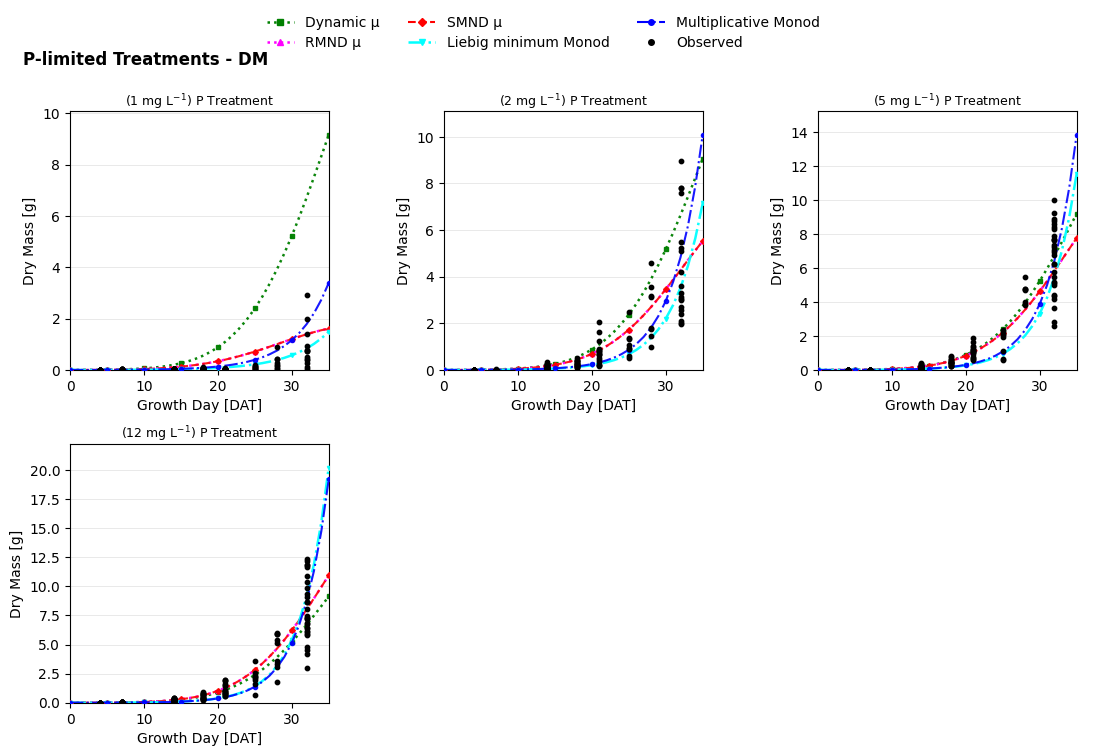

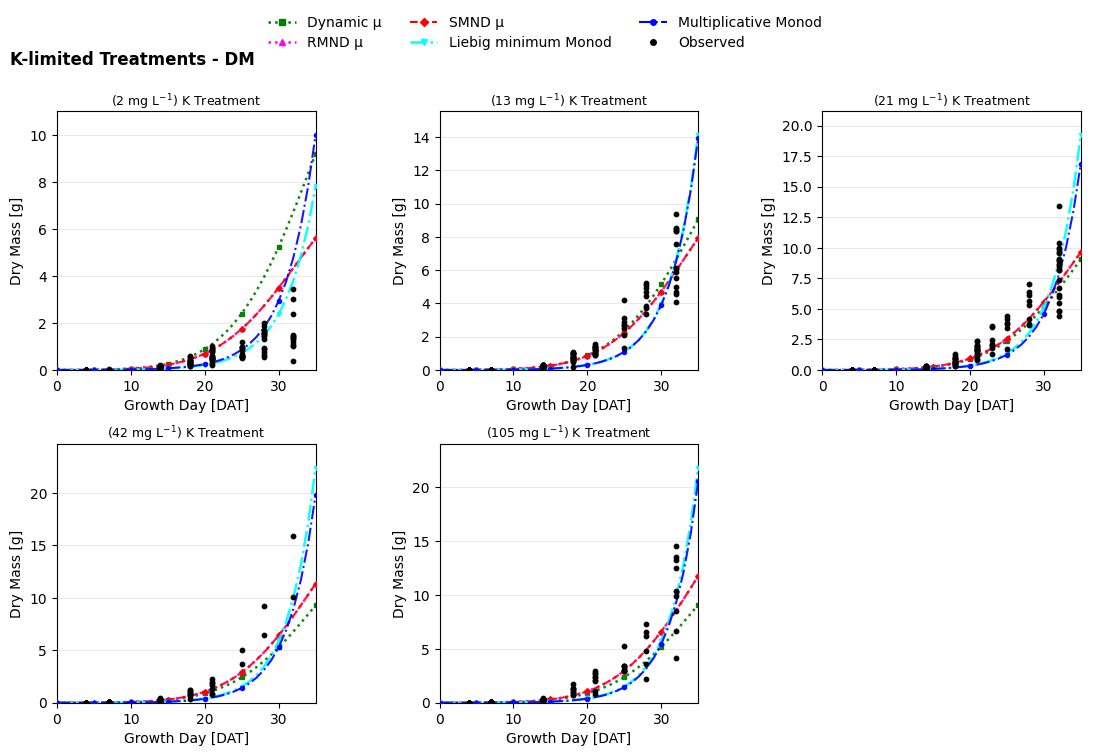

In [3]:
MODEL_DISPLAY_ALL = {
    "dynamic": "Dynamic μ",
    "rmnd": "RMND μ",
    "smnd": "SMND μ",
    "liebig": "Liebig minimum Monod",
    "multiplicative": "Multiplicative Monod",
}


def evaluate_one_model_all(plot_df_dm, fit_df_dm, model_name, params):
    results = {}
    treatment_rows_dm = []

    for treatment, sub_plot in plot_df_dm.groupby("Treatment"):
        sub_plot = sub_plot.sort_values("Growth Day").reset_index(drop=True)
        sub_fit = fit_df_dm[fit_df_dm["Treatment"] == treatment].sort_values("Growth Day").reset_index(drop=True)

        if len(sub_fit) < 2:
            continue

        category = sub_fit["Category"].iloc[0]
        forcing = build_treatment_forcing(sub_fit)
        days_obs = sub_fit["Growth Day"].values.astype(float)

        y_dm_obs = sub_fit["Y_DM"].values.astype(float)
        B0_dm = float(y_dm_obs[0])

        t_grid, y_dm_plot, y_dm_fit = simulate_biomass(
            model_name, forcing, params, category, B0_dm, days_obs
        )

        met_dm = metrics_dict(y_dm_obs, y_dm_fit)

        treatment_rows_dm.append({
            "Model": MODEL_DISPLAY_ALL[model_name],
            "Category": display_category_label_all(category),
            "Treatment": display_treatment_label(treatment),
            "R2": met_dm["R2"],
            "MAE": met_dm["MAE"],
            "RMSE": met_dm["RMSE"],
        })

        results[treatment] = {
            "category": category,
            "data_plot": sub_plot,
            "t_grid": t_grid,
            "Y_DM_plot": y_dm_plot,
            "Y_DM_fit": y_dm_fit,
        }

    treatment_df_dm = pd.DataFrame(treatment_rows_dm)

    overall_dm = metrics_dict(
        np.concatenate([fit_df_dm[fit_df_dm["Treatment"] == t]["Y_DM"].values for t in results.keys()]),
        np.concatenate([results[t]["Y_DM_fit"] for t in results.keys()])
    )

    return results, treatment_df_dm, overall_dm


def plot_category_panels_overlay_all(all_model_results, category):
    ordered = [t for t in CATEGORY_TREATMENT_ORDER_ALL[category] if t in all_model_results["dynamic"]]
    if len(ordered) == 0:
        return

    n_panels = len(ordered)
    ncols = 3
    nrows = int(math.ceil(n_panels / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(11.5, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    style_map = {
        "dynamic":        dict(color="green",   linestyle=":",  linewidth=1.8, alpha=0.95, zorder=2, marker="s"),
        "rmnd":           dict(color="magenta", linestyle=":",  linewidth=1.8, alpha=0.95, zorder=3, marker="^"),
        "smnd":           dict(color="red",     linestyle="--", linewidth=1.5, alpha=0.90, zorder=4, marker="D"),
        "liebig":         dict(color="cyan",    linestyle="-.", linewidth=1.8, alpha=0.95, zorder=5, marker="v"),
        "multiplicative": dict(color="blue",    linestyle="-.", linewidth=1.5, alpha=0.90, zorder=6, marker="o"),
    }

    model_order = ["dynamic", "rmnd", "smnd", "liebig", "multiplicative"]

    for i, treatment in enumerate(ordered):
        ax = axes[i]
        ax.axis("on")

        sub = all_model_results["dynamic"][treatment]["data_plot"]
        y_obs = sub["Y_DM"].values
        x_obs = sub["Growth Day"].values

        ax.scatter(x_obs, y_obs, color="black", s=10, zorder=10)

        for model_name in model_order:
            x_plot = all_model_results[model_name][treatment]["t_grid"]
            y_plot = all_model_results[model_name][treatment]["Y_DM_plot"]
            style = style_map[model_name]

            ax.plot(
                x_plot, y_plot,
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                alpha=style["alpha"],
                zorder=style["zorder"],
            )
            ax.plot(
                x_plot[::5], y_plot[::5],
                linestyle="None",
                marker=style["marker"],
                markersize=3.0,
                color=style["color"],
                alpha=style["alpha"],
                zorder=style["zorder"] + 0.1,
            )

        ax.set_title(display_treatment_label(treatment), fontsize=9, pad=4)
        ax.set_xlabel("Growth Day [DAT]")
        ax.set_ylabel("Dry Mass [g]")
        ax.grid(axis="y", color="#d9d9d9", linewidth=0.4)
        ax.set_xlim(0, 35)
        ax.set_box_aspect(1)

        ymax = max([np.nanmax(y_obs)] + [
            np.nanmax(all_model_results[m][treatment]["Y_DM_plot"]) for m in model_order
        ])
        ax.set_ylim(0, ymax * 1.10)

    title = f"{display_category_label_all(category)} Treatments - DM"
    axes[0].text(
        -0.18, 1.18, title,
        transform=axes[0].transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left"
    )

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="green",   lw=1.8, ls=":",  marker="s", markersize=4, label="Dynamic μ"),
        Line2D([0], [0], color="magenta", lw=1.8, ls=":",  marker="^", markersize=4, label="RMND μ"),
        Line2D([0], [0], color="red",     lw=1.5, ls="--", marker="D", markersize=4, label="SMND μ"),
        Line2D([0], [0], color="cyan",    lw=1.8, ls="-.", marker="v", markersize=4, label="Liebig minimum Monod"),
        Line2D([0], [0], color="blue",    lw=1.5, ls="-.", marker="o", markersize=4, label="Multiplicative Monod"),
        Line2D([0], [0], marker="o", color="black", lw=0, markersize=4, label="Observed"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.995))
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Evaluate all models on all treatment categories
all_eval_all = {}
all_model_results_all = {}

for model_name in ["dynamic", "rmnd", "smnd", "liebig", "multiplicative"]:
    results, treatment_df_dm, overall_dm = evaluate_one_model_all(
        plot_df_dm_all, fit_df_dm_all, model_name, fitted_params_all[model_name]
    )

    all_eval_all[model_name] = {
        "results": results,
        "treatment_df_dm": treatment_df_dm,
        "overall_dm": overall_dm,
    }
    all_model_results_all[model_name] = results

# Print model-wise metrics
for model_name in ["dynamic", "rmnd", "smnd", "liebig", "multiplicative"]:
    print(f"\n{'=' * 80}\nMODEL: {MODEL_DISPLAY_ALL[model_name]}\n{'=' * 80}")
    print("\nPer-treatment metrics — DM")
    print(all_eval_all[model_name]["treatment_df_dm"].round(4).to_string(index=False))
    print("\nOverall metrics — DM")
    print({k: round(v, 4) if pd.notna(v) else v for k, v in all_eval_all[model_name]["overall_dm"].items()})

# Plot all categories
for category in ALL_CATEGORIES:
    plot_category_panels_overlay_all(all_model_results_all, category)

In [ ]:
# Bootstrap 95% CI for N-limited downstream validation metrics
# Same style as integrated model validation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def collect_downstream_prediction_pairs(all_model_results, fit_df_dm, model_name, category_filter="N"):
    y_true_all = []
    y_pred_all = []

    results = all_model_results[model_name]

    for treatment, res in results.items():
        sub_fit = (
            fit_df_dm[fit_df_dm["Treatment"] == treatment]
            .sort_values("Growth Day")
            .reset_index(drop=True)
        )

        if category_filter is not None:
            if "Category" in sub_fit.columns:
                if str(sub_fit["Category"].iloc[0]).upper() != str(category_filter).upper():
                    continue

        if len(sub_fit) < 2:
            continue

        y_true = sub_fit["Y_DM"].values.astype(float)
        y_pred = np.asarray(res["Y_DM_fit"], dtype=float)

        if len(y_true) != len(y_pred):
            raise ValueError(
                f"Length mismatch for {model_name}, treatment {treatment}: "
                f"y_true={len(y_true)}, y_pred={len(y_pred)}"
            )

        y_true_all.append(y_true)
        y_pred_all.append(y_pred)

    if len(y_true_all) == 0:
        raise ValueError(f"No validation data collected for model {model_name}.")

    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


def bootstrap_metric_ci(y_true, y_pred, n_boot=5000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = len(y_true)
    if n < 2:
        raise ValueError("Need at least two observations for bootstrap CI.")

    boot_r2 = []
    boot_mae = []
    boot_rmse = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)

        yt = y_true[idx]
        yp = y_pred[idx]

        boot_mae.append(mean_absolute_error(yt, yp))
        boot_rmse.append(np.sqrt(mean_squared_error(yt, yp)))

        if np.nanstd(yt) == 0:
            boot_r2.append(np.nan)
        else:
            boot_r2.append(r2_score(yt, yp))

    boot_r2 = np.asarray(boot_r2, dtype=float)
    boot_mae = np.asarray(boot_mae, dtype=float)
    boot_rmse = np.asarray(boot_rmse, dtype=float)

    alpha = (100 - ci) / 2

    summary = {
        "R2": {
            "estimate": r2_score(y_true, y_pred),
            "ci_lower": np.nanpercentile(boot_r2, alpha),
            "ci_upper": np.nanpercentile(boot_r2, 100 - alpha),
        },
        "MAE": {
            "estimate": mean_absolute_error(y_true, y_pred),
            "ci_lower": np.nanpercentile(boot_mae, alpha),
            "ci_upper": np.nanpercentile(boot_mae, 100 - alpha),
        },
        "RMSE": {
            "estimate": np.sqrt(mean_squared_error(y_true, y_pred)),
            "ci_lower": np.nanpercentile(boot_rmse, alpha),
            "ci_upper": np.nanpercentile(boot_rmse, 100 - alpha),
        },
    }

    return summary


downstream_bootstrap_rows = []

for model_name in ["dynamic", "rmnd", "smnd", "liebig", "multiplicative"]:
    y_true, y_pred = collect_downstream_prediction_pairs(
        all_model_results_all,
        fit_df_dm_all,
        model_name,
        category_filter="N"   # use None if you want all categories
    )

    ci_summary = bootstrap_metric_ci(
        y_true,
        y_pred,
        n_boot=5000,
        ci=95,
        random_state=42
    )

    downstream_bootstrap_rows.append({
        "Model": MODEL_DISPLAY_ALL[model_name],
        "R2": ci_summary["R2"]["estimate"],
        "R2 95% CI lower": ci_summary["R2"]["ci_lower"],
        "R2 95% CI upper": ci_summary["R2"]["ci_upper"],
        "MAE (g)": ci_summary["MAE"]["estimate"],
        "MAE 95% CI lower (g)": ci_summary["MAE"]["ci_lower"],
        "MAE 95% CI upper (g)": ci_summary["MAE"]["ci_upper"],
        "RMSE (g)": ci_summary["RMSE"]["estimate"],
        "RMSE 95% CI lower (g)": ci_summary["RMSE"]["ci_lower"],
        "RMSE 95% CI upper (g)": ci_summary["RMSE"]["ci_upper"],
        "n": len(y_true),
    })

downstream_bootstrap_ci_df = pd.DataFrame(downstream_bootstrap_rows)

print("\nDownstream validation bootstrap 95% confidence intervals")
print(downstream_bootstrap_ci_df.round(4).to_string(index=False))

downstream_bootstrap_ci_df.to_csv(
    "downstream_validation_bootstrap_metric_ci.csv",
    index=False
)


Downstream validation bootstrap 95% confidence intervals
               Model     R2  R2 95% CI lower  R2 95% CI upper  MAE (g)  MAE 95% CI lower (g)  MAE 95% CI upper (g)  RMSE (g)  RMSE 95% CI lower (g)  RMSE 95% CI upper (g)  n
           Dynamic μ 0.7679           0.7087           0.8440   0.4389                0.2401                0.6811    0.9849                 0.4764                 1.4685 59
              RMND μ 0.6862           0.0861           0.8666   0.5509                0.3170                0.8250    1.1452                 0.6355                 1.6147 59
              SMND μ 0.6862           0.0861           0.8666   0.5509                0.3170                0.8250    1.1452                 0.6355                 1.6147 59
Liebig minimum Monod 0.6573           0.0186           0.8891   0.5254                0.2755                0.8273    1.1967                 0.6203                 1.7223 59
Multiplicative Monod 0.6333          -0.0697           0.8801   0.5399  